In [6]:
!pip install rdkit     #installing rdkit

###**Lipinski's Rule of 5**

In [11]:
from rdkit import Chem

In [15]:
from rdkit.Chem import AllChem

In [18]:
from rdkit.Chem import Descriptors

In [25]:
# 1. pasting the smiles string here
smiles_string = "CC(=O)OC1=CC=CC=C1C(=O)O"  #This is Aspirin

# 2. Telling rdkit to convert smiles string into 3D chemical object
molecule = Chem.MolFromSmiles(smiles_string)

# 3. calculate molecular weight and Logp (How easily the molecule crosses the cell membrane)
mol_weight = Descriptors.MolWt(molecule)
mol_logp = Descriptors.MolLogP(molecule)

# 4. Print the results
print(f"Molecular weight: {mol_weight} g/mol")
print(f"LogP (lipophilicity) : {mol_logp}")

# 5. The filter
if mol_weight < 500 and mol_logp < 5:
  print("This molecule has good drug-like properties!")
else:
  print("This molecule might be too large or greacy to work as an oral drug.")



Molecular weight: 180.15899999999996 g/mol
LogP (lipophilicity) : 1.3101
This molecule has good drug-like properties!


### Generate and visualize 2D and 3D structures

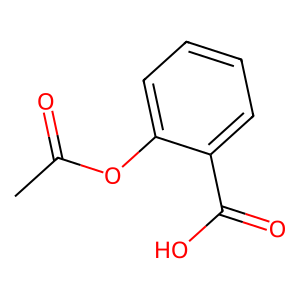

In [29]:
# Generate 2D structure of molecule
AllChem.Compute2DCoords(molecule)

# Display the 2D structure
from rdkit.Chem.Draw import MolToImage
img_2d = MolToImage(molecule)
display(img_2d)

### Generate and Optimize 3D Structure

In [32]:
!pip install py3Dmol -q
import py3Dmol

# Generate 3D coordinates for the molecule
# Add hydrogens for more realistic 3D structure
molecule_3d = Chem.AddHs(molecule)

# Embed a 3D conformation (generate initial coordinates)
AllChem.EmbedMolecule(molecule_3d)

# Optimize the 3D conformation using the Universal Force Field (UFF)
AllChem.UFFOptimizeMolecule(molecule_3d)

# Create the 3D visualization
view = py3Dmol.view(width=400, height=400)
# Convert RDKit molecule to Mol block for py3Dmol
mb = Chem.MolToMolBlock(molecule_3d)
view.addModel(mb, 'mol')
view.setStyle({'stick': {}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.